# Sprint 1 — Análise Exploratória de Dados

## Classificação Automática de Autos de Infração Ambiental utilizando PLN

Nesta etapa foi utilizada a base pública de autos de infração do IBAMA. A análise foi feita para entender a qualidade dos dados, a distribuição das categorias e as características das descrições antes do treinamento dos modelos.

Para o problema de classificação, os dois campos principais são:

- `DES_AUTO_INFRACAO`: descrição textual do auto;
- `TIPO_INFRACAO`: categoria da infração.


In [1]:

# Bibliotecas
import io
import re
import csv
import zipfile
import unicodedata
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)


## 1. Carregamento dos dados

Os arquivos foram obtidos diretamente da base pública do IBAMA. O conjunto é dividido em arquivos por ano, que foram reunidos em um único DataFrame.


In [2]:

URL_DATASET = (
    "https://stibamadadosabertosprd.blob.core.windows.net/"
    "dados-abertos/dados/SIFISC/auto_infracao/auto_infracao/auto_infracao_csv.zip"
)

print("Baixando o dataset oficial do IBAMA...")
resp = requests.get(URL_DATASET, timeout=180)
resp.raise_for_status()

print(f"Download concluído: {len(resp.content) / 1024**2:.1f} MB")
z = zipfile.ZipFile(io.BytesIO(resp.content))
csv_files = [n for n in z.namelist() if n.lower().endswith(".csv")]

print(f"Arquivos CSV encontrados no ZIP: {len(csv_files)}")
for nome in csv_files[:20]:
    print(" -", nome)


Baixando o dataset oficial do IBAMA...
Download concluído: 115.9 MB
Arquivos CSV encontrados no ZIP: 48
 - auto_infracao_1977.csv
 - auto_infracao_1980.csv
 - auto_infracao_1981.csv
 - auto_infracao_1982.csv
 - auto_infracao_1983.csv
 - auto_infracao_1984.csv
 - auto_infracao_1985.csv
 - auto_infracao_1986.csv
 - auto_infracao_1987.csv
 - auto_infracao_1988.csv
 - auto_infracao_1989.csv
 - auto_infracao_1990.csv
 - auto_infracao_1991.csv
 - auto_infracao_1992.csv
 - auto_infracao_1993.csv
 - auto_infracao_1994.csv
 - auto_infracao_1995.csv
 - auto_infracao_1996.csv
 - auto_infracao_1997.csv
 - auto_infracao_1998.csv


In [3]:

def normalizar_nome_coluna(nome):
    nome = unicodedata.normalize("NFKD", str(nome)).encode("ascii", "ignore").decode("ascii")
    nome = nome.strip().lower()
    nome = re.sub(r"[^a-z0-9]+", "_", nome)
    return nome.strip("_")

COLUNAS_DESEJADAS = {
    "seq_auto_infracao",
    "num_auto_infracao",
    "ser_auto_infracao",
    "tipo_auto",
    "tipo_multa",
    "val_auto_infracao",
    "des_auto_infracao",
    "dat_hora_auto_infracao",
    "cod_municipio",
    "municipio",
    "uf",
    "cod_infracao",
    "des_infracao",
    "tipo_infracao",
    "qtd_area",
    "qt_area",
    "infracao_area",
    "classificacao_area",
    "des_local_infracao",
    "tipo_acao",
    "operacao",
}

def detectar_leitura(zip_obj, membro):
    erros = []
    for encoding in ("utf-8", "latin-1", "cp1252"):
        for sep in (";", ",", "|", "\t"):
            try:
                with zip_obj.open(membro) as f:
                    cab = pd.read_csv(f, sep=sep, encoding=encoding, nrows=0)
                if len(cab.columns) >= 5:
                    return encoding, sep, list(cab.columns)
            except Exception as e:
                erros.append((encoding, sep, str(e)[:100]))
    raise RuntimeError(f"Não foi possível detectar o formato de {membro}. Exemplos: {erros[:3]}")

def carregar_csv_relevante(zip_obj, membro):
    encoding, sep, colunas_originais = detectar_leitura(zip_obj, membro)
    mapa = {c: normalizar_nome_coluna(c) for c in colunas_originais}
    usecols = [c for c in colunas_originais if mapa[c] in COLUNAS_DESEJADAS]

    if not usecols:
        print(f"Ignorado {membro}: nenhuma coluna de interesse encontrada.")
        return None

    with zip_obj.open(membro) as f:
        parte = pd.read_csv(
            f,
            sep=sep,
            encoding=encoding,
            usecols=usecols,
            low_memory=False,
            on_bad_lines="skip",
        )

    parte = parte.rename(columns=mapa)
    print(
        f"{membro}: {len(parte):,} linhas | "
        f"{len(parte.columns)} colunas | encoding={encoding!r} | sep={sep!r}"
    )
    return parte

partes = []
for membro in csv_files:
    parte = carregar_csv_relevante(z, membro)
    if parte is not None:
        partes.append(parte)

if not partes:
    raise RuntimeError("Nenhum CSV compatível foi carregado.")

df = pd.concat(partes, ignore_index=True)
del partes

print("\nDimensão consolidada:", df.shape)
df.head()


auto_infracao_1977.csv: 2 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1980.csv: 10 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1981.csv: 98 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1982.csv: 295 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1983.csv: 135 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1984.csv: 251 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1985.csv: 661 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1986.csv: 617 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1987.csv: 829 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1988.csv: 2,611 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1989.csv: 1,423 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1990.csv: 3,387 linhas | 20 colunas | encoding='utf-8' | sep=';'
auto_infracao_1991.csv: 2,121 linhas | 20 colunas | encoding='utf-8' | sep

,seq_auto_infracao,num_auto_infracao,ser_auto_infracao,tipo_auto,tipo_multa,val_auto_infracao,des_auto_infracao,dat_hora_auto_infracao,cod_municipio,municipio,uf,cod_infracao,des_infracao,tipo_infracao,qt_area,infracao_area,classificacao_area,des_local_infracao,tipo_acao,operacao
0,645774.0,961297,A,Multa simples,NaN,"107,00",POR PRATICAR ATO DE PESCA AMADORISTICA COM PETRECHO PROIBIDO PELO ORGAO COMPETENTE,1977-10-16,3530607.0,MOGI DAS CRUZES,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,759674.0,145566,B,Multa simples,NaN,"107,00",PRATICA DE PESCA COM UTILIZACAO DE PETRECHOS PROIBIDOS.,1977-09-03,3169356.0,TRES MARIAS,MG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,482955.0,11,A,Multa simples,NaN,"130000,00","Utilizar, transportar, armazenar, embalar, receber, consumir, comercializar produtos ou sub-produtos florestais sem cobertura de guia florestal (atpf).",1980-03-15,5208707.0,GOIANIA,GO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,482956.0,14,A,Multa simples,NaN,"82275,00","Utilizar, transportar, armazenar, embalar, receber, consumir, comercializar produtos ou sub-produtos florestais sem cobertura de guia florestal (atpf).",1980-03-26,5208707.0,GOIANIA,GO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,484007.0,139,a,Multa simples,NaN,"5820,00","Utilizar, explorar, comercializar, industrializar sob qualquer forma especimes da flora e da fauna silvestre, seus produtos e sub-produtos sem o previo registro.",1980-08-12,5219704.0,SANTA TEREZINHA DE GOIAS,GO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Visão geral da base

In [4]:

print(f"Registros: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
display(pd.DataFrame({
    "coluna": df.columns,
    "tipo": [str(t) for t in df.dtypes],
    "nao_nulos": [df[c].notna().sum() for c in df.columns],
    "nulos": [df[c].isna().sum() for c in df.columns],
    "unicos": [df[c].nunique(dropna=True) for c in df.columns],
}))


Registros: 709,176
Colunas: 20


,coluna,tipo,nao_nulos,nulos,unicos
0,seq_auto_infracao,float64,702749,6427,702749
1,num_auto_infracao,object,709176,0,638341
2,ser_auto_infracao,object,618816,90360,39
3,tipo_auto,object,709144,32,3
4,tipo_multa,object,175549,533627,4
5,val_auto_infracao,object,698014,11162,64275
6,des_auto_infracao,object,694238,14938,550640
7,dat_hora_auto_infracao,object,709176,0,265589
8,cod_municipio,float64,708909,267,5477
9,municipio,object,708909,267,6286


A base carregada possui **709.176 registros e 20 colunas**. Nem todos os campos serão usados no modelo; vários servem apenas para entender melhor os dados.

### Exemplos de registros

In [5]:

campos_centrais = [
    c for c in ["num_auto_infracao", "des_auto_infracao", "des_infracao",
                "tipo_infracao", "uf", "dat_hora_auto_infracao"]
    if c in df.columns
]
df[campos_centrais].sample(min(10, len(df)), random_state=42)


,num_auto_infracao,des_auto_infracao,des_infracao,tipo_infracao,uf,dat_hora_auto_infracao
449775,678645,"Destruir 38,0234 há de floresta amazônica,considerada objeto de especial preservação,consumada por uso do fogo,sem autorização do órgão ambiental competente.",Infração da Flora(Não Classificada-Móvel),Flora,AM,2010-09-29 00:00:00
442927,470601,"TER EM DEPOSITO 10,980M3 MADEIRA EM TORA ESSÊNCIA LOURO VERMELHO. OBS AI LAVRADO EM SUBSTITUIÇÃO AO AI 412692/D, PROC. 02047.000669/04-22","Receber, adquirir ou ter em depósito produto florestal sem cobertura de ATPF ou com ATPF falsificada.",Flora,PA,2009-10-13 11:45:00
66198,299059,Pescar em epocas (piracema) e nos locais interditados pelo orgao competente item I pescador desembarcado paragr unico com barco menor de 08 metros.,NaN,NaN,GO,1997-11-23 00:00:00
268241,71423,"CAUSOU DANO DIRETO A ÁREA DE PROTEÇÃO AMBIENTAL.DESTRUIU COM EXPLOSIVOS JAZIDAS DE MINÉRIOS(DE PEDRAS), NO RIACHO DA CACHOEIRA TAMANDUÁ",NaN,NaN,AL,2003-01-22 00:00:00
693148,MSULV907,"Omitir atividade em sistema oficial de controle ao não informar a categoria 3 ¿ 10 Fabricação de artefatos de ferro, aço e de metais não-ferrosos com ou sem tratamento de super...",Infração de Administração Ambiental(Não Classificada-Móvel),Administração Ambiental,SP,2025-10-09 10:23:43
362672,195342,"TER EM CATIVEIRO PASSAROS DA FAUNA SILVESTRE SEM REGISTRO JUNTO AO ORGAO COMPETENTE, 03 SANHAÇO.",NaN,NaN,RS,2007-09-17 00:00:00
543260,9061499,"Ter em cativeiro um espécime da fauna silvestre nativa sem a devida permissão, licença ou autorização da autoridade ambiental competente.",Infração da Fauna(Não Classificada-Móvel),Fauna,CE,2015-05-26 11:09:00
569702,9113204,"UTILIZAR ESPÉCIME SILVESTRE (TRINCA-FERRO PORTADOR DA ANILHA IBAMA OA 3,5 434123) EM DESACORDO COM A LICENÇA DE CRIADOR AMADORISTA. TRATA-SE DE ANILHA INAUTÊNTICA CONFORME CONS...",Infração da Fauna(Não Classificada-Móvel),Fauna,ES,2016-08-18 11:07:00
368826,560972,"MANTER EM CATIVEIRO ANIMAIS/PASSÁROS/AVES DA FAUNA SILVESTRE BRASILEIRA, SEM AUTORIZAÇÃO DO ÓRGÃO COMPETENTE (IBAMA)",NaN,NaN,MG,2007-10-11 15:20:00
105010,78683,"Por explorar seletivamente florestas e mata amazonia legal, sem autorização do IBAMA,no ato da fiscalização foi constado in loco, exploração total de 144,776 M3.",NaN,NaN,MT,1998-06-21 00:00:00


## 3. Valores ausentes

,percentual_ausente,quantidade_ausente
operacao,93.290241,661592
qt_area,93.263590,661403
tipo_multa,75.246060,533627
classificacao_area,70.379003,499111
des_local_infracao,69.282378,491334
tipo_acao,68.546031,486112
infracao_area,68.156001,483346
cod_infracao,39.911390,283042
des_infracao,39.911390,283042
tipo_infracao,39.911390,283042


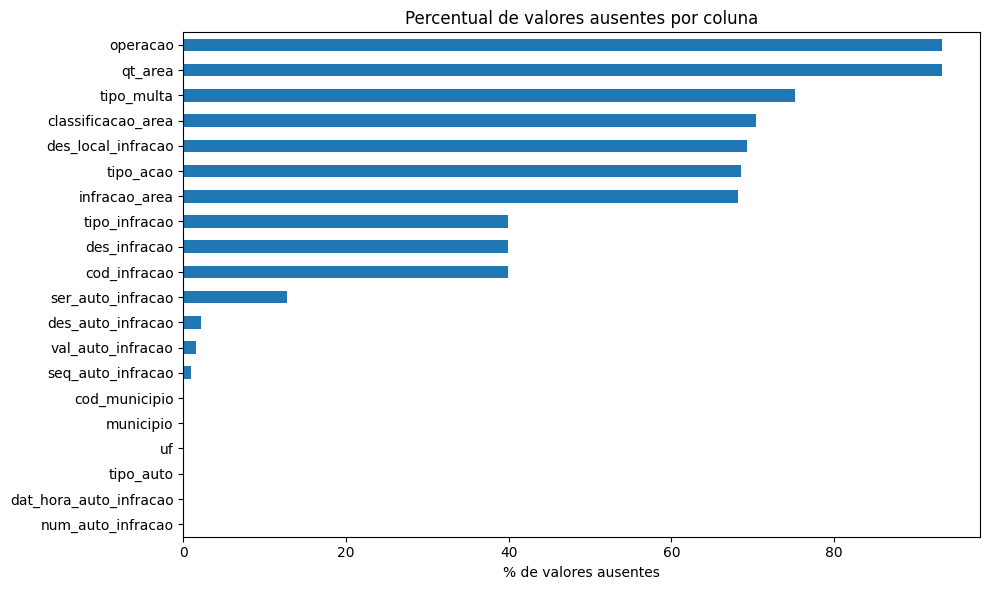

In [6]:

ausentes = (
    df.isna().mean().mul(100)
      .sort_values(ascending=False)
      .rename("percentual_ausente")
      .to_frame()
)
ausentes["quantidade_ausente"] = df.isna().sum()
display(ausentes)

plt.figure(figsize=(10, 6))
ausentes["percentual_ausente"].sort_values().plot(kind="barh")
plt.title("Percentual de valores ausentes por coluna")
plt.xlabel("% de valores ausentes")
plt.tight_layout()
plt.show()


Para treinar um classificador supervisionado, é necessário ter tanto a descrição quanto a categoria preenchidas. Por isso foi verificada a quantidade de registros que possuem os dois campos.

In [7]:

obrigatorios = [c for c in ["des_auto_infracao", "tipo_infracao"] if c in df.columns]
if len(obrigatorios) < 2:
    raise KeyError(
        "O dataset carregado não contém simultaneamente "
        "'des_auto_infracao' e 'tipo_infracao'. Verifique os nomes das colunas."
    )

df["des_auto_infracao"] = df["des_auto_infracao"].astype("string").str.strip()
df["tipo_infracao"] = df["tipo_infracao"].astype("string").str.strip()

validos = (
    df["des_auto_infracao"].notna()
    & df["tipo_infracao"].notna()
    & df["des_auto_infracao"].ne("")
    & df["tipo_infracao"].ne("")
)

print(f"Registros totais: {len(df):,}")
print(f"Registros utilizáveis (texto + alvo): {validos.sum():,}")
print(f"Percentual utilizável: {validos.mean()*100:.2f}%")

dados = df.loc[validos].copy()


Registros totais: 709,176
Registros utilizáveis (texto + alvo): 425,670
Percentual utilizável: 60.02%


Dos 709.176 registros, **425.670 (60,02%)** possuem `DES_AUTO_INFRACAO` e `TIPO_INFRACAO` preenchidos e podem ser usados inicialmente no problema de classificação. O campo de categoria é o que mais reduz a quantidade de registros utilizáveis, pois está ausente em cerca de 40% da base.

## 4. Duplicidades e inconsistências

In [8]:

print(f"Linhas totalmente duplicadas: {df.duplicated().sum():,}")
print(
    "Descrições textuais repetidas:",
    f"{dados['des_auto_infracao'].duplicated().sum():,}"
)

duplicados_texto_classe = dados.duplicated(
    subset=["des_auto_infracao", "tipo_infracao"]
).sum()

print(
    "Pares texto + categoria repetidos:",
    f"{duplicados_texto_classe:,}"
)

# Mesma descrição associada a mais de uma classe
classes_por_texto = (
    dados.groupby("des_auto_infracao")["tipo_infracao"]
         .nunique()
         .sort_values(ascending=False)
)

ambiguos = classes_por_texto[classes_por_texto > 1]
print(f"Descrições associadas a mais de uma categoria: {len(ambiguos):,}")

if len(ambiguos):
    display(ambiguos.head(20).to_frame("numero_de_categorias"))


Linhas totalmente duplicadas: 0
Descrições textuais repetidas: 39,750
Pares texto + categoria repetidos: 38,547
Descrições associadas a mais de uma categoria: 986


,numero_de_categorias
des_auto_infracao,
Não informado,10
Deixar de atender a exigências legais quando devidamente notificado pela autoridade ambiental competente no prazo concedido.,7
Dificultar a ação do Poder Público no exercício de atividades de fiscalização ambiental.,7
Portar motosserra sem licença da autoridade ambiental competente.,6
Dificultar a ação do Poder Público no exercício de atividade de fiscalização ambiental.,6
Deixar de inscrever-se no Cadastro Técnico Federal.,6
Dificultar a ação do poder público no exercício de atividades de fiscalização ambiental.,6
Deixar de atender a exigências legais ou regulamentares quando devidamente notificado pela autoridade ambiental competente no prazo concedido.,6
"Deixar de atender a exigências legais ou regulamentares quando devidamente notificado pela autoridade ambiental competente no prazo concedido, visando à regularização, correção ou adoção de medidas de controle para cessar a degradação ambiental.",6


Foram encontrados **38.547 pares repetidos de descrição e categoria**. Também existem **986 descrições associadas a mais de uma categoria**. Alguns casos são textos genéricos, como “Não informado”, então esses registros precisam ser tratados antes de separar treino e teste para evitar resultados distorcidos.

## 5. Distribuição das categorias

Quantidade de categorias em TIPO_INFRACAO: 12


,quantidade
tipo_infracao,
Flora,217458
Fauna,65974
Cadastro Técnico Federal,36648
Controle Ambiental,34574
Pesca,32944
Outras,11587
Administração Ambiental,9165
Qualidade Ambiental,6919
Unidade de Conservação,3577


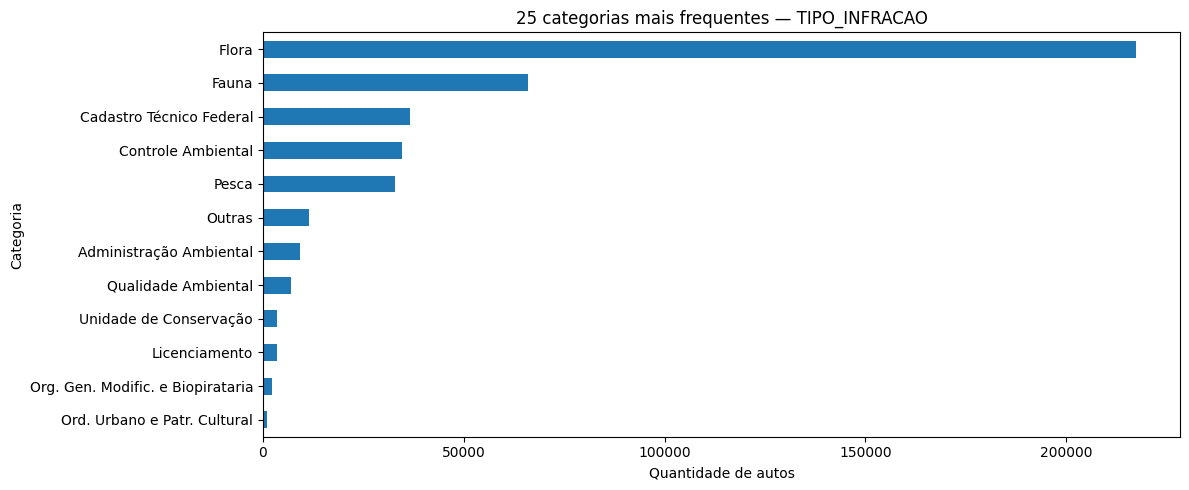

In [9]:

contagem_classes_raw = dados["tipo_infracao"].value_counts()

print(f"Quantidade de categorias em TIPO_INFRACAO: {contagem_classes_raw.size}")
display(contagem_classes_raw.head(30).to_frame("quantidade"))

plt.figure(figsize=(12, max(5, min(12, 0.35 * min(25, len(contagem_classes_raw))))))
contagem_classes_raw.head(25).sort_values().plot(kind="barh")
plt.title("25 categorias mais frequentes — TIPO_INFRACAO")
plt.xlabel("Quantidade de autos")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()


A base possui **12 categorias**. A classe `Flora` aparece com bastante diferença em relação às demais, com 217.458 registros, enquanto a menor classe possui 934 registros. Portanto, existe um desbalanceamento considerável entre as classes, o que deverá ser levado em conta na avaliação dos modelos.

## 6. Tamanho das descrições

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
n_caracteres,425670.0,161.878901,90.582507,1.0,36.0,54.0,100.0,144.0,203.0,327.0,479.0,1751.0
n_palavras,425670.0,23.511706,13.243164,1.0,5.0,8.0,15.0,20.0,29.0,48.0,70.0,269.0


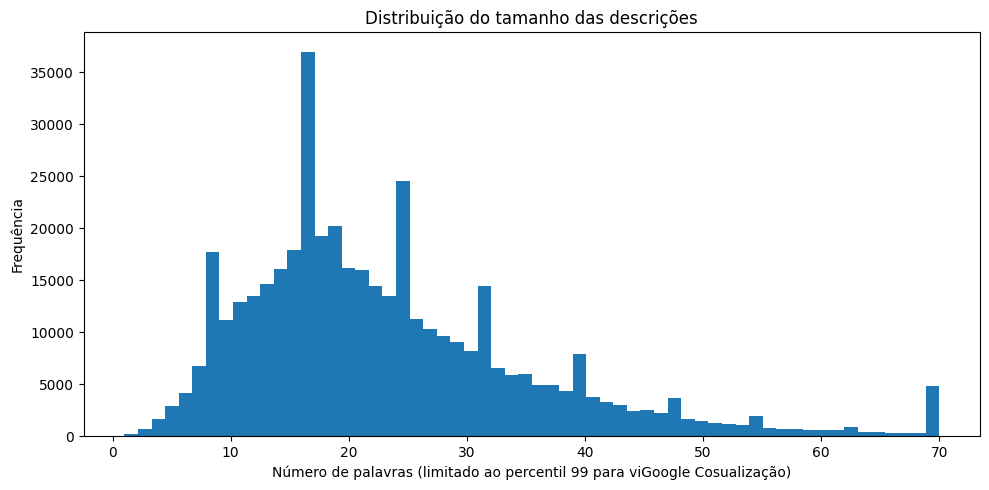

In [10]:

dados["n_caracteres"] = dados["des_auto_infracao"].str.len()
dados["n_palavras"] = dados["des_auto_infracao"].str.split().str.len()

display(
    dados[["n_caracteres", "n_palavras"]]
    .describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])
    .T
)

plt.figure(figsize=(10, 5))
dados["n_palavras"].clip(upper=dados["n_palavras"].quantile(.99)).plot(
    kind="hist", bins=60
)
plt.title("Distribuição do tamanho das descrições")
plt.xlabel("Número de palavras (limitado ao percentil 99 para viGoogle Cosualização)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()


In [11]:

# Textos muito curtos podem conter pouca informação semântica
for limite in (3, 5, 10):
    qtd = (dados["n_palavras"] <= limite).sum()
    print(
        f"Descrições com até {limite} palavras: "
        f"{qtd:,} ({qtd/len(dados)*100:.2f}%)"
    )

display(
    dados.loc[dados["n_palavras"].nsmallest(20).index,
              ["des_auto_infracao", "tipo_infracao", "n_palavras"]]
    .sort_values("n_palavras")
)


Descrições com até 3 palavras: 928 (0.22%)
Descrições com até 5 palavras: 5,513 (1.30%)
Descrições com até 10 palavras: 45,305 (10.64%)


,des_auto_infracao,tipo_infracao,n_palavras
5275,OUTROS.,Flora,1
16555,ghhggh,Flora,1
112879,403001,Flora,1
131981,ioiuouioui,Flora,1
163117,XXXXX,Flora,1
232699,.,Flora,1
258463,Desmatar,Flora,1
260692,Tranportar,Flora,1
318492,06559719987,Flora,1
450847,advertência,Pesca,1


A mediana é de **20 palavras por descrição**. A maioria dos textos possui informação suficiente para uma classificação textual, mas existem registros muito curtos ou claramente inválidos, como códigos isolados, pontos e textos de teste. Esses casos deverão ser filtrados no pré-processamento.

## 7. Distribuição dos registros por ano

Como a base do IBAMA já é separada em arquivos anuais, a distribuição abaixo usa a quantidade de registros carregados de cada arquivo. Isso evita problemas de interpretação do formato da coluna de data.


,quantidade
2012,18978
2013,16184
2014,15292
2015,17325
2016,17823
2017,16885
2018,17884
2019,14525
2020,9529
2021,9661


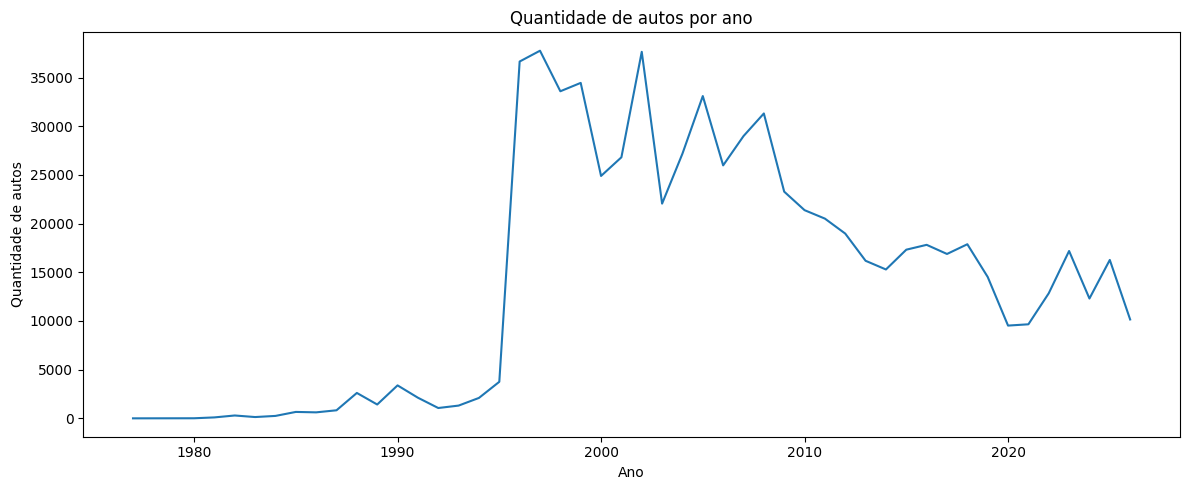

In [12]:
anos_arquivos = [1977, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
quantidades_arquivos = [2, 10, 98, 295, 135, 251, 661, 617, 829, 2611, 1423, 3387, 2121, 1063, 1312, 2099, 3755, 36651, 37761, 33597, 34456, 24898, 26814, 37646, 22056, 27189, 33104, 25983, 28991, 31316, 23285, 21384, 20516, 18978, 16184, 15292, 17325, 17823, 16885, 17884, 14525, 9529, 9661, 12847, 17190, 12308, 16272, 10157]

registros_por_ano = pd.Series(
    {ano: qtd for ano, qtd in zip(anos_arquivos, quantidades_arquivos)},
    name="quantidade"
)

display(registros_por_ano.tail(15).to_frame())

plt.figure(figsize=(12, 5))
registros_por_ano.plot()
plt.title("Quantidade de autos por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de autos")
plt.tight_layout()
plt.show()


A quantidade de autos varia bastante ao longo dos anos. Há crescimento forte a partir da década de 1990 e oscilações nos anos mais recentes. Essa diferença temporal pode ser relevante posteriormente para avaliar se o padrão dos textos mudou com o tempo.

## 8. Distribuição por estado

,quantidade
uf,
PA,50409
MG,40303
MT,36292
RO,29499
CE,22186
AM,21108
SP,19882
RS,18262
ES,17031


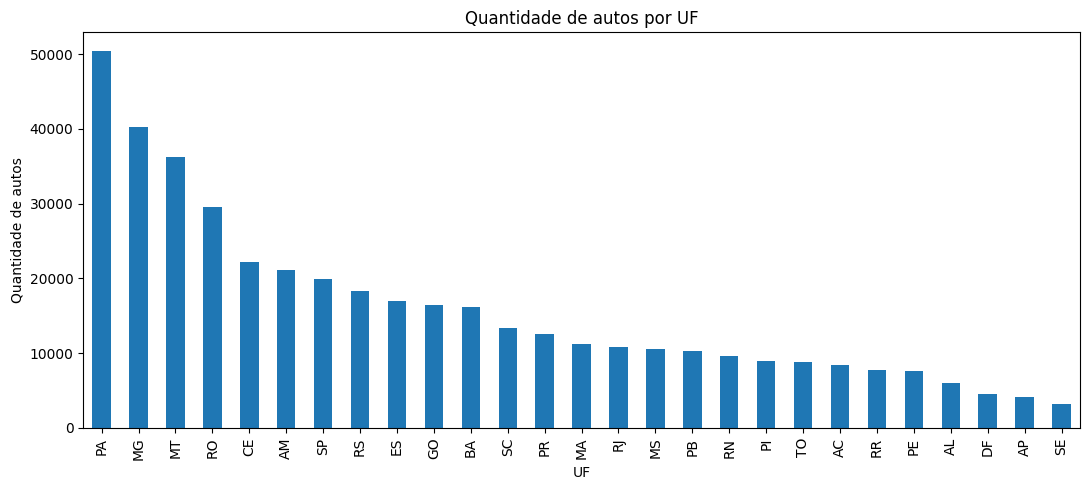

In [13]:

if "uf" in dados.columns:
    por_uf = dados["uf"].astype("string").str.strip().value_counts()

    display(por_uf.to_frame("quantidade"))

    plt.figure(figsize=(11, 5))
    por_uf.sort_values(ascending=False).plot(kind="bar")
    plt.title("Quantidade de autos por UF")
    plt.xlabel("UF")
    plt.ylabel("Quantidade de autos")
    plt.tight_layout()
    plt.show()
else:
    print("Coluna UF não encontrada.")


Entre os registros utilizáveis, os estados com maior quantidade de autos são Pará, Minas Gerais e Mato Grosso. A distribuição geográfica também não é uniforme, mas nesta primeira versão do projeto a UF será usada apenas na análise, e não como entrada do classificador.

## 9. Verificação de campos que podem revelar a classe

In [16]:
if "des_infracao" in dados.columns:
    aux = dados.dropna(subset=["des_infracao", "tipo_infracao"]).copy()
    aux["des_infracao"] = aux["des_infracao"].astype("string").str.strip()

    qtd_descricoes_padronizadas = aux["des_infracao"].nunique()
    print(f"DES_INFRACAO distintas: {qtd_descricoes_padronizadas:,}")

    classes_por_des_padronizada = (
        aux.groupby("des_infracao")["tipo_infracao"].nunique()
    )

    pct_mapeamento_unico = (
        (classes_por_des_padronizada == 1).mean() * 100
        if len(classes_por_des_padronizada) else np.nan
    )

    print(
        "Percentual de descrições padronizadas ligadas a apenas uma classe:",
        f"{pct_mapeamento_unico:.2f}%"
    )

    print(
        "\nComo DES_INFRACAO está fortemente relacionada com TIPO_INFRACAO, "
        "esse campo não será usado como entrada do modelo."
    )
else:
    print("DES_INFRACAO não encontrada.")

DES_INFRACAO distintas: 444
Percentual de descrições padronizadas ligadas a apenas uma classe: 97.07%

Como DES_INFRACAO está fortemente relacionada com TIPO_INFRACAO, esse campo não será usado como entrada do modelo.


O campo `DES_INFRACAO` está fortemente ligado à categoria: **97,07% das descrições padronizadas aparecem associadas a apenas uma classe**. Por isso ele não deve ser usado como entrada do modelo, já que poderia praticamente entregar a resposta. O foco será classificar usando o texto livre de `DES_AUTO_INFRACAO`.

## 10. Conclusões da EDA

A base é adequada para continuar o projeto, pois possui mais de 425 mil registros com descrição e categoria preenchidas. A EDA também mostrou alguns pontos que precisarão ser tratados antes do treinamento:

- remover ou revisar textos vazios, muito curtos e registros de teste;
- tratar descrições duplicadas antes da divisão entre treino e teste;
- considerar o forte desbalanceamento entre as 12 categorias;
- não utilizar `DES_INFRACAO` como atributo do modelo;
- usar `DES_AUTO_INFRACAO` como entrada e `TIPO_INFRACAO` como classe.

Na próxima Sprint, esses dados serão preparados para o treinamento e comparação dos primeiros modelos de classificação.
